# FisherLike

This notebook implements a flowPINN for the FisherLike PDE

## Preliminaries

Whether to run computations on GPU or CPU

In [1]:
import os

USE_GPU: bool = True

if not USE_GPU:
    os.environ['JAX_PLATFORM_NAME'] = 'cpu'
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(0)
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

Package imports

In [2]:
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal, norm

import optax
from jax import config, devices

import pickle
from functools import partial
from typing import Callable

import os

# ensure that we can access flowpinns
import sys
sys.path.append('../../')

from flowpinns.training_utils import init_learner
from flowpinns.data_utils import DataLoader
from flowpinns import inverse_autoregressive_flow
from flowpinns import parameterised_PINN
from flowpinns import objective_fns
from flowpinns.flow_setup import initialise_flow 
from flowpinns import utils
from flowpinns.utils import *

Uncomment below for debugging

In [3]:
# config.update("jax_debug_nans", True)

Check what devices are available

In [4]:
devices()

[CudaDevice(id=0)]

### Specify the experiment settings 

In [5]:
# -----------------------------------------------------------------------------
# Random seed
# -----------------------------------------------------------------------------

# Base PRNG key used for the experiment
rng_key = jr.key(2061)


# -----------------------------------------------------------------------------
# Observation configuration
# -----------------------------------------------------------------------------

# Number of noisy solution-space observations
Nu: int = 25

# -----------------------------------------------------------------------------
# Experiment configuration container
# -----------------------------------------------------------------------------

# Dictionary storing all experiment settings
SETTINGS = {}


# -----------------------------------------------------------------------------
# PDE parameter configuration
# -----------------------------------------------------------------------------

# Initial estimate of the PDE parameter vector theta.
# Used only for initialising the flow and PINN models.
SETTINGS['theta_init']: Array = jnp.array([2., 2.])

# Dimensionality of the parameter vector theta
SETTINGS['D_theta'] = SETTINGS['theta_init'].shape[0]

# Nonlinear transforms used to enforce parameter constraints
# (e.g. positivity of theta and noise parameters)
SETTINGS['theta_transform']: Callable = utils.softplus
SETTINGS['noise_transform']: Callable = utils.softplus


# -----------------------------------------------------------------------------
# Data storage
# -----------------------------------------------------------------------------

# We provide one regeneration of the underlying data 
data_save_dir: str = f'../data/fisherlike'
assert os.path.isdir(data_save_dir)


# -----------------------------------------------------------------------------
# Prior distribution on SoftPlus(theta)
# -----------------------------------------------------------------------------

# Mean and standard deviation of the Gaussian prior on SoftPlus(theta)
SETTINGS['prior_mean']: float = 4.
SETTINGS['prior_std']: float = 2.


# -----------------------------------------------------------------------------
# Normalising flow configuration
# -----------------------------------------------------------------------------

# Architecture of the normalising flow
SETTINGS['flow_depth']: int = 1
SETTINGS['flow_width']: int = 128
SETTINGS['n_flows']: int = 4        # Number of flow layers (K in Eq. 3)


# -----------------------------------------------------------------------------
# PINN architecture
# -----------------------------------------------------------------------------

# Width and depth of the parameterised PINN
SETTINGS['pinn_width']: int = 40
SETTINGS['pinn_depth']: int = 4


# -----------------------------------------------------------------------------
# ELBO estimation
# -----------------------------------------------------------------------------

# Number of theta samples used when approximating the ELBO
SETTINGS['n_theta_samples_elbo']: int = 100


# -----------------------------------------------------------------------------
# Stage One training configuration
# -----------------------------------------------------------------------------

# Size of the data subsample used during Stage One training
# (denoted M in Eq. 13 of the paper). Must not exceed Nu.
# Choose the lowest value that yields a stable estimate
# of yf_noise_std
SETTINGS['stage_one_batch_size']: int = 5
assert SETTINGS['stage_one_batch_size'] <= Nu


# -----------------------------------------------------------------------------
# Stage Two training configuration
# -----------------------------------------------------------------------------

# Number of PDE collocation points used per optimisation step
SETTINGS['stage_two_batch_size']: int = 128

# Number of theta samples used for PINN loss function in Stage Two
SETTINGS['n_theta_samples_s2']: int = 50


# -----------------------------------------------------------------------------
# Training schedule
# -----------------------------------------------------------------------------

# Number of optimisation steps for each stage of training
SETTINGS['n_train_s1']: int = 100000
SETTINGS['n_train_pinn_s2']: int = 50000
SETTINGS['n_train_flow_s3']: int = 25000

# Short training schedule used for debugging
# SETTINGS['n_train_s1']: int = 5000
# SETTINGS['n_train_pinn_s2']: int = 5000
# SETTINGS['n_train_flow_s3']: int = 1000 


# -----------------------------------------------------------------------------
# Optimisation settings
# -----------------------------------------------------------------------------

# Initial learning rate used across training stages
SETTINGS['lr_init']: float = 1e-4

### Data processing

Create directory to save results and settings

In [6]:
total_n_train = SETTINGS['n_train_s1'] + SETTINGS['n_train_pinn_s2'] + SETTINGS['n_train_flow_s3']
results_save_dir_base = f"results/fisherlike/flowPINN/Nu_{Nu}_Nbatch_{SETTINGS['stage_one_batch_size']}_K_{SETTINGS['n_flows']}_n_train_{total_n_train}"

save_dirs = SaveDirs.create(results_save_dir_base)

save_dict_to_txt(SETTINGS, os.path.join(save_dirs.base, f"SETTINGS.txt"))
save_dirs.base

'results/fisherlike/flowPINN/Nu_25_Nbatch_5_K_4_n_train_175000'

Load data. The collocation data are stored in ``(X_f, y_f)``, and the noisy solution space data are stored in ``(X_u, y_u)``

In [7]:
train_data = load_train_data(data_save_dir, Nu)
train_data.Xf.shape, train_data.yf.shape, train_data.Xu.shape, train_data.yu.shape

((1000, 2), (1000,), (25, 2), (25,))

Place train_data in a DataLoader for batch training

In [8]:
train_data_loader = DataLoader(train_data, SETTINGS['stage_one_batch_size'], SETTINGS['stage_two_batch_size'])

In [9]:
rng_use_elbo, rng_use_pinn, rng_key = jr.split(rng_key, 3)
elbo_validation_batch = train_data_loader.get_fixed_batch(rng_use_elbo, Nbatch_f=train_data_loader.Nu*3)
pinn_validation_batch = train_data_loader.get_colloc_batch(rng_use_pinn, Nbatch_f=SETTINGS['stage_two_batch_size'])

Keep track of the dimensions of the data

In [10]:
D_in = train_data.Xu.shape[-1]
D_out = 1

Useful for intialising the PINN

In [11]:
x_init = train_data.Xu[0]

### Initialise Normalising Flow

In [12]:
key_use, rng_key = jr.split(rng_key, 2)
flow_sampler, flow_params_init = initialise_flow(key_use, SETTINGS)

Plot samples from the prior distribution over $\theta$

In [13]:
key_use, rng_key = jr.split(rng_key, 2)
n_prior_samples = 1000
prior_theta_samples = SETTINGS['theta_transform'](flow_sampler.prior_sample(key_use, n_prior_samples))

In [14]:
SETTINGS['prior_mean'], prior_theta_samples.mean(0), SETTINGS['prior_std'], prior_theta_samples.std(0)

(4.0,
 Array([4.0914087, 4.072272 ], dtype=float32),
 2.0,
 Array([1.877969 , 1.8435881], dtype=float32))

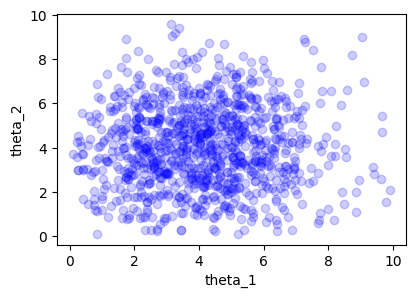

In [15]:
plot_theta_samples(prior_theta_samples, save_name= os.path.join(save_dirs.plots, f'prior_theta_samples_plot.pdf'))

Plot samples from the flow distribution over $\theta$ with randomly initialised flow parameters

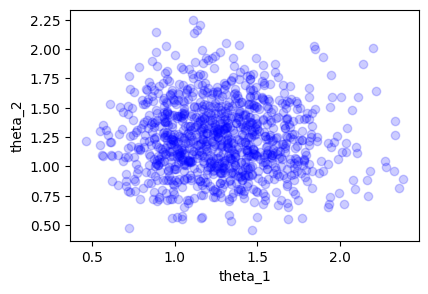

In [16]:
use_key, rng_key = jr.split(rng_key, 2)
theta_z, log_det_jacobian = flow_sampler.posterior_sample(key_use, n_prior_samples, flow_params_init)
flow_theta_samples_init = SETTINGS['theta_transform'](theta_z)
plot_theta_samples(flow_theta_samples_init, save_name= os.path.join(save_dirs.plots, f'flow_samples_at_initialisation.pdf'))

### Initialise Parameterised PINN 

First define an approximate distance function and mean function which together ensure that the Dirichlet condition is exactly enforced by the parmameterised PINN. This is discussed in Appendix E.7.1 of the paper.

In [17]:
# ---------------------------------------------------------------------
# Domain definition
# ---------------------------------------------------------------------

# Lower and upper bounds of the spatio-temporal domain:
# x ∈ [lb[0], ub[0]], t ∈ [lb[1], ub[1]]
lb = jnp.array([-5.0, 0.0])   # (x_min, t_min)
ub = jnp.array([5.0, 10.0])   # (x_max, t_max)

# Spatial domain length (used for interpolation in mean_fn)
domain_length = ub[0] - lb[0]


# ---------------------------------------------------------------------
# Helper: analytic profile (previously u_true, now internal)
# ---------------------------------------------------------------------

def _profile(x: Array, t: Array) -> FloatArray:
    """
    Analytic travelling-wave profile used to define
    initial and boundary conditions.

    This replaces the need for a globally defined `u_true`.
    """
    return 0.5 - 0.5 * jnp.tanh(
        1.0 + 0.25 * jnp.sqrt(2.0) * (x - t / jnp.sqrt(2.0))
    )


# ---------------------------------------------------------------------
# Initial and boundary conditions
# ---------------------------------------------------------------------

def t0_fn(x: Array) -> FloatArray:
    """
    Initial condition at t = t_min.

    u(x, t_min)
    """
    return _profile(x, lb[1])


def lb_fn(t: Array) -> FloatArray:
    """
    Boundary condition at x = x_min.

    u(x_min, t)
    """
    return _profile(lb[0], t)


def ub_fn(t: Array) -> FloatArray:
    """
    Boundary condition at x = x_max.

    u(x_max, t)
    """
    return _profile(ub[0], t)


# Corner values at (x_min, t_min) and (x_max, t_min)
# These ensure consistency when constructing the mean function
u_lb_t0 = lb_fn(lb[1])
u_ub_t0 = ub_fn(lb[1])


# ---------------------------------------------------------------------
# Mean function
# ---------------------------------------------------------------------

def mean_fn(loc: Array) -> FloatArray:
    """
    Mean function that satisfies:
      - initial condition at t = t_min
      - boundary conditions at x = x_min and x = x_max

    Constructed via linear interpolation in space, correcting
    from the initial condition to match boundary values over time.
    """
    x,t = loc
    return (
        t0_fn(x)
        # Contribution from right boundary (x_max)
        + (ub_fn(t) - u_ub_t0) * ((x - lb[0]) / domain_length)
        # Contribution from left boundary (x_min)
        + (lb_fn(t) - u_lb_t0) * ((ub[0] - x) / domain_length)
    )


# ---------------------------------------------------------------------
# Vanishing (envelope) function
# ---------------------------------------------------------------------

def adf(loc: Array) -> FloatArray:
    """
    Spatio-temporal envelope function.

    Vanishes at:
      - x = x_min
      - x = x_max
      - t = 0

    Used to enforce boundary/initial conditions in
    trial solutions (e.g. PINNs or kernel methods).
    """
    x,t = loc
    return ((ub[0] - x) * (x - lb[0]) * t) / 250.0

We use a simplified [parameterised PINN]((https://arxiv.org/abs/2408.09446v1)) in which the PDE parameters are concatenated directly with the spatial inputs. We also experimented with the two-branch architecture proposed by the authors, but observed little difference in results

In [18]:
pinn_model = parameterised_PINN.SimpleP2INN([SETTINGS['pinn_width']]*SETTINGS['pinn_depth'] + [D_out], adf=adf, mean_fn=mean_fn)

use_key, rng_key = jr.split(rng_key, 2)
pinn_params_init = pinn_model.init(use_key, x_init, SETTINGS['theta_init'])

Define a prediction function for the PDE solution $u$ which makes a prediction for a single spatial location / PDE parameter pair

In [19]:
upred_fn = pinn_model.apply
upred_fn(pinn_params_init, x_init, SETTINGS['theta_init'])

Array(0.10035127, dtype=float32)

Vmap to allow for predictions are multiple input locations with common PDE parameter value $\theta$

In [71]:
upred_vmap = jax.vmap(upred_fn, in_axes=[None,0, None])
upred_vmap(pinn_params_init, train_data.Xu, SETTINGS['theta_init']).shape, train_data.yu.shape

((25,), (25,))

### Specify the differential operator

This experiment involves a Fisher-like equation over one spatial dimension:
$$\mathcal{F}_{\boldsymbol{\theta}}[u]
= \frac{\partial u}{\partial t} - \theta_1\frac{\partial^2 u}{\partial x^2} - \theta_2 u^2(1-u) = f = 0, \quad (x,t) \in (-5,5) \times (0,10],
$$

Here $u(x,t)$ denotes the solution field and $\boldsymbol{\theta} = (\theta_1,\theta_2)$ are the PDE coefficients.

The function below constructs the differential operator $\mathcal{F}_{\boldsymbol{\theta}}$ for a given neural network representation of  $u$.  
Applying the operator to the network yields the corresponding right-hand side (RHS) function $f$.

In [21]:
def apply_PDE_pinn(fn: Callable, theta_transform: Callable) -> Callable:
    """
    Construct a function that applies the FisherLike PDE operator to a PINN.
    """

    # define new function which splits x and t to make autodiff easier
    def split_fn(params, x, t, theta_z):
        loc = jnp.array([x,t])
        return fn(params, loc, theta_z)


    # first time derivative and second spatial derivative
    ut_fn  = jax.grad(split_fn, argnums=2)
    uxx_fn = jax.grad(jax.grad(split_fn, argnums=1),argnums=1)

    def pde_operator(params: Dict, loc: Array, theta_z: Array) -> FloatArray:
        """
        Evaluate the FisherLike PDE at single spatio/temporal location loc, given
        (raw scale) PDE parameter vector theta
        """

        x, t = loc

        u_val   = split_fn(params, x, t, theta_z)
        ut_val  = ut_fn(params, x, t, theta_z)
        uxx_val = uxx_fn(params, x, t, theta_z)
        
        # Transform PDE parameters to physical scale
        theta1, theta2 = theta_transform(theta_z)

        return_val =  ut_val - theta1*uxx_val - theta2*(u_val**2)*(1. - u_val)
        
        return return_val.squeeze()

    return pde_operator

Define a prediction function for the PDE forcing $f$ which makes a prediction for a single spatial location / PDE parameter pair

In [22]:
fpred_fn = apply_PDE_pinn(upred_fn, SETTINGS['theta_transform'])
fpred_fn(pinn_params_init, x_init, SETTINGS['theta_init'])

Array(-0.03972576, dtype=float32)

Vmap to allow for predictions are multiple input locations with common PDE parameter value $\boldsymbol{\theta}$

In [70]:
fpred_vmap = jax.vmap(fpred_fn, in_axes=[None,0, None])
fpred_vmap(pinn_params_init, train_data.Xf, SETTINGS['theta_init']).shape, train_data.yf.shape

((1000,), (1000,))

Vmap again over different values of $\boldsymbol{\theta}$

In [69]:
fpred_vmap2 = jax.vmap(fpred_vmap, in_axes=[None,None, 0])

fpred_vmap2(pinn_params_init, train_data.Xf, jnp.tile(SETTINGS['theta_init'].reshape(-1,1),2).T).shape, train_data.yf.shape

((2, 1000), (1000,))

## FlowPINN Model Training

We perform training in three sequential stages, following the description in Section 4.1 of the paper:

- **Stage One:** Train the `flow`, `pinn`, and `likelihood` parameters jointly using a **subsampled ELBO**. At each training step, only `stage_one_batch_size` (< `Nu`) solution-space observations are used.

- **Stage Two:** Train the `pinn` parameters while keeping the `flow` and `likelihood` parameters fixed from Stage One.

- **Stage Three:** Train the `flow` and `likelihood` parameters on the ELBO using **all `Nu` observations**, with the `pinn` parameters held fixed from Stage Two.

This staged training strategy helps to prevent overfitting of the flow posterior

### Stage One Training

Initialise the flow, PINN and likelihood parameters

In [25]:
params_init = {}
params_init['flow_params'] = flow_params_init 
params_init['pinn_params'] = pinn_params_init

# initialise noise std to 5% of the level seen in the training data
yu_noise_init = train_data_loader.yu.std()*.05
yf_noise_init = 0.25
params_init['likelihood_params'] = SETTINGS['noise_transform'](jnp.array([yu_noise_init, yf_noise_init]), True)

Define the objective function

In [26]:
s1_elbo_obj_fn, s1_posterior =  objective_fns.get_elbo_objective_fn(SETTINGS, flow_sampler, upred_vmap, fpred_vmap)

Initialise the learner

In [27]:
s1_rng, rng_key = jr.split(rng_key, 2)

s1_train_batch_loader = train_data_loader.get_batch

stage1_learner = init_learner(
    stage = "stage1",
    params = params_init,
    loss_fn = s1_elbo_obj_fn,
    learning_rate = SETTINGS['lr_init'],
    rng = s1_rng,
    noise_transform = SETTINGS['noise_transform'],
    train_batch_loader = s1_train_batch_loader,
    validation_batch = elbo_validation_batch
)

Uncomment below to check that everything runs correctly

In [28]:
# use_key1, use_key2, use_key3 = jr.split(jr.key(0), 3)
# check_batch = s1_train_batch_loader(use_key2)

# _ = s1_posterior(SETTINGS['theta_init'], params_init, check_batch)
# _ = s1_elbo_obj_fn(params_init, use_key1, check_batch)
# _ = stage1_learner.train_step_fn(stage1_learner.opt_state, params_init, use_key2)

Uncomment below to update the learning rate of the Adam optimiser

In [29]:
# stage1_learner.opt_state.hyperparams['learning_rate'] /=  2.

Train the ``flow``, ``pinn`` and ``yu_noise_std`` likelihood parameters jointly

In [72]:
stage1_learner.train(1) # run one train step for jit compilation

In [31]:
stage1_learner.train(SETTINGS['n_train_s1'])

(2), Obj/Valid: 1120.30/3804.40, lr: 1.0e-04, sample mean/std: [1.2787206 1.2724977]/[0.33899438 0.29687417], noise_stds: 1.758e-02/2.500e-01
(10002), Obj/Valid: -11.40/-151.17, lr: 1.0e-04, sample mean/std: [1.5109906 1.5366435]/[0.28732982 0.34358364], noise_stds: 1.717e-02/1.040e-01
(20002), Obj/Valid: -16.85/-212.70, lr: 1.0e-04, sample mean/std: [1.4895561 1.2771913]/[0.21702233 0.19649851], noise_stds: 1.030e-02/4.763e-02
(30002), Obj/Valid: -19.04/-242.17, lr: 1.0e-04, sample mean/std: [1.2788427 1.1553086]/[0.14129668 0.13933708], noise_stds: 8.127e-03/3.151e-02
(40002), Obj/Valid: -19.50/-254.49, lr: 1.0e-04, sample mean/std: [1.1719213 1.0877472]/[0.13515839 0.1193114 ], noise_stds: 7.520e-03/2.593e-02
(50002), Obj/Valid: -19.85/-262.75, lr: 1.0e-04, sample mean/std: [1.0951174 1.0572495]/[0.13031659 0.09936544], noise_stds: 7.040e-03/2.323e-02
(60002), Obj/Valid: -21.52/-267.15, lr: 1.0e-04, sample mean/std: [1.0438818 1.0561049]/[0.14055747 0.09388558], noise_stds: 6.728e-0

Save the trained parameters

In [32]:
stage1_trained_params = stage1_learner.params.copy()

In [33]:
with open(os.path.join(save_dirs.nn_params, f's1_params.pkl'), 'wb') as fp:
    pickle.dump(stage1_trained_params, fp)

In [34]:
del stage1_learner

Plot and save the Stage One Posterior samples of $\theta$

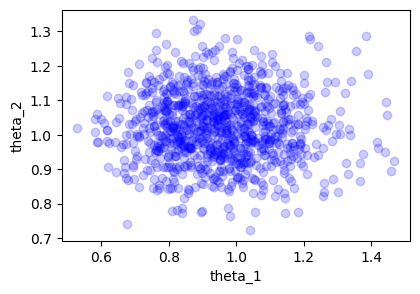

In [35]:
use_key, rng_key = jr.split(rng_key, 2)

s1_theta_z, log_det_jacobian = flow_sampler.posterior_sample(key_use, n_prior_samples, stage1_trained_params['flow_params'])
s1_theta_samples = SETTINGS['theta_transform'](s1_theta_z)

plot_theta_samples(s1_theta_samples, save_name= os.path.join(save_dirs.plots, f's1_theta_samples_plot.pdf'))

### Stage Two Training

Define the objective function

In [36]:
s2_obj_fn = partial(objective_fns.pinn_obj_fn, pred_fn_vmap2=fpred_vmap2)

Initialise the learner

In [37]:
s2_rng, rng_key = jr.split(rng_key, 2)

s2_train_batch_loader = train_data_loader.get_colloc_batch

s2_flow_sampler = lambda key: flow_sampler.posterior_sample(key, SETTINGS['n_theta_samples_s2'], stage1_trained_params['flow_params'])[0]

stage2_learner = init_learner(
    stage = "stage2",
    params = stage1_trained_params['pinn_params'],
    loss_fn = s2_obj_fn,
    noise_transform = SETTINGS['noise_transform'],
    learning_rate = SETTINGS['lr_init'],
    rng = s2_rng,
    train_batch_loader = s2_train_batch_loader,
    validation_batch = pinn_validation_batch,
    flow_sampler = s2_flow_sampler,
)

Uncomment below to check that everything runs correctly

In [38]:
# use_key1, use_key2, use_key3 = jr.split(jr.key(0), 3)
# Xf_batch, yf_batch = s2_train_batch_loader(use_key2)

# _ = s2_obj_fn(stage2_learner.params, s1_theta_samples[:10], Xf_batch, yf_batch)
# _ = stage2_learner.train_step_fn(stage2_learner.opt_state, stage2_learner.params, use_key2)

Uncomment below to update the learning rate of the Adam optimiser

In [39]:
# stage2_learner.opt_state.hyperparams['learning_rate'] /=  2.

Train the ``pinn`` parameters with the ``flow`` and ``yu_noise_std`` likelihood parameters held fixed

In [73]:
stage2_learner.train(1) # run one train step for jit compilation

In [41]:
stage2_learner.train(SETTINGS['n_train_pinn_s2'])

(2), Obj/Valid: 4.075e-04/3.698e-04, lr: 1.0e-04
(5002), Obj/Valid: 1.550e-05/1.223e-05, lr: 1.0e-04
(10002), Obj/Valid: 7.374e-06/5.438e-06, lr: 1.0e-04
(15002), Obj/Valid: 2.702e-06/3.233e-06, lr: 1.0e-04
(20002), Obj/Valid: 2.145e-06/2.266e-06, lr: 1.0e-04
(25002), Obj/Valid: 2.722e-06/1.828e-06, lr: 1.0e-04
(30002), Obj/Valid: 1.516e-06/1.793e-06, lr: 1.0e-04
(35002), Obj/Valid: 2.005e-06/1.417e-06, lr: 1.0e-04
(40002), Obj/Valid: 1.594e-06/1.248e-06, lr: 1.0e-04
(45002), Obj/Valid: 8.362e-07/1.064e-06, lr: 1.0e-04
(50001), Obj/Valid: 9.471e-07/8.426e-07, lr: 1.0e-04


Save the trained parameters

In [42]:
stage2_trained_pinn_params = stage2_learner.params.copy()

Use Stage 2 loss value to give a final estimate of  ``yf_noise_std``, which is fixed in Stage Three training

In [43]:
fixed_yf_noise_std = stage2_learner.loss**.5

In [44]:
with open(os.path.join(save_dirs.nn_params, f's2_pinn_params.pkl'), 'wb') as fp:
    pickle.dump(stage2_trained_pinn_params, fp)

In [45]:
del stage2_learner

### Stage Three Training

Define the objective function

In [46]:
s3_elbo_obj_fn, s3_posterior =  objective_fns.get_elbo_objective_fn(SETTINGS, flow_sampler, upred_vmap, fpred_vmap, stage2_trained_pinn_params, fixed_yf_noise_std)

Initialise the trainable parameters

In [47]:
s3_yu_noise_std_init = SETTINGS['noise_transform'](stage1_trained_params['likelihood_params'][0])
s3_yu_noise_std_init, fixed_yf_noise_std 

(Array(0.00556727, dtype=float32), Array(0.00097317, dtype=float32))

In [48]:
s3_params_init = {}
s3_params_init['flow_params']       = stage1_trained_params['flow_params']
s3_params_init['likelihood_params'] = SETTINGS['noise_transform'](jnp.array([s3_yu_noise_std_init, fixed_yf_noise_std]), True)

Initialise the learner

In [49]:
s3_rng, valid_rng, rng_key = jr.split(rng_key, 3)

s3_train_batch_loader = lambda rng: train_data_loader.get_fixed_batch(rng, Nbatch_f=train_data_loader.Nu)
valid_batch = train_data_loader.get_fixed_batch(valid_rng, Nbatch_f=train_data_loader.Nu*3)

stage3_learner = init_learner(
    stage = "stage3",
    params = s3_params_init,
    loss_fn = s3_elbo_obj_fn,
    learning_rate = SETTINGS['lr_init'],
    rng = s3_rng,
    noise_transform = SETTINGS['noise_transform'],
    train_batch_loader = s3_train_batch_loader,
    validation_batch = elbo_validation_batch,
)

Uncomment below to check that everything runs correctly

In [50]:
# use_key1, use_key2, use_key3 = jr.split(jr.key(0), 3)
# check_batch = s3_train_batch_loader(use_key2)

# _ = s3_posterior(SETTINGS['theta_init'], stage3_learner.params, check_batch)
# _ = s3_elbo_obj_fn(stage3_learner.params, use_key1, check_batch)
# _ = stage3_learner.train_step_fn(stage3_learner.opt_state, stage3_learner.params, use_key2)

Uncomment below to update the learning rate of the Adam optimiser

In [51]:
# stage3_learner.opt_state.hyperparams['learning_rate'] /=  2.

Train the ``flow`` and ``yu_noise_std`` likelihood parameter, with the ``pinn`` parameters held fixed

In [74]:
stage3_learner.train(1) # run one train step for jit compilation

In [53]:
stage3_learner.train(SETTINGS['n_train_flow_s3'])

(2), Obj/Valid: 214.59/-139.00, lr: 1.0e-04, sample mean/std: [0.96115875 1.0262761 ]/[0.17102899 0.11270341], noise_stds: 5.568e-03/9.732e-04
(2502), Obj/Valid: -119.16/-418.73, lr: 1.0e-04, sample mean/std: [0.9875702 1.0259622]/[0.08808491 0.03794933], noise_stds: 6.699e-03/9.732e-04
(5002), Obj/Valid: -165.57/-460.55, lr: 1.0e-04, sample mean/std: [0.97167003 1.0263284 ]/[0.0578591  0.02038399], noise_stds: 7.939e-03/9.732e-04
(7502), Obj/Valid: -181.80/-478.82, lr: 1.0e-04, sample mean/std: [0.9709654 1.0237237]/[0.04930112 0.01325591], noise_stds: 9.531e-03/9.732e-04
(10002), Obj/Valid: -192.32/-488.52, lr: 1.0e-04, sample mean/std: [0.97744155 1.0213566 ]/[0.0330528  0.01135392], noise_stds: 1.147e-02/9.732e-04
(12502), Obj/Valid: -197.10/-493.45, lr: 1.0e-04, sample mean/std: [0.97380847 1.0220155 ]/[0.03768295 0.01441578], noise_stds: 1.369e-02/9.732e-04
(15002), Obj/Valid: -198.33/-495.47, lr: 1.0e-04, sample mean/std: [0.9827318 1.0200231]/[0.04224715 0.01564891], noise_stds

Save the trained parameters

In [54]:
stage3_trained_params = stage3_learner.params.copy()

In [55]:
with open(os.path.join(save_dirs.nn_params, f's3_params.pkl'), 'wb') as fp:
    pickle.dump(stage3_trained_params, fp)

In [56]:
del stage3_learner

## Results evaluation

Load ground truth data

In [57]:
theta_true = jnp.array([1., 1.])

test_data = load_test_data(data_save_dir)

test_data.Xs.shape, test_data.us.shape

((8000, 2), (8000,))

Uncomment the below to load pre-trained flow / PINN parameter values

In [58]:
# with open(os.path.join(save_dirs.nn_params, f's2_pinn_params.pkl'), 'rb') as f:
#     trained_pinn_params = pickle.load(f)

# with open(os.path.join(save_dirs.nn_params, f's3_params.pkl'), 'rb') as f:
#     trained_flow_params = pickle.load(f)['flow_params']

In [59]:
trained_pinn_params = stage2_trained_pinn_params
trained_flow_params = stage3_trained_params['flow_params']

In [60]:
trained_pinn = jax.jit(lambda Xs, theta_z: upred_vmap(trained_pinn_params, Xs, theta_z))
trained_flow = jax.jit(lambda key: flow_sampler.posterior_sample(key, n_theta_samples, trained_flow_params)[0])

n_theta_samples: int = 1000
n_us_samples   : int = 100

Sample from trained posterior

In [61]:
use_key, rng_key = jr.split(rng_key, 2)

theta_z_samples = trained_flow(use_key)

theta_samples = SETTINGS['theta_transform'](theta_z_samples)

print(f"theta_samples_mean: {theta_samples.mean(axis=0)}")
print(f"theta_samples_std : {theta_samples.std(axis=0)}")

theta_samples_mean: [0.983654  1.0221696]
theta_samples_std : [0.0458542  0.01804398]


In [62]:
us_samples = jax.vmap(trained_pinn, in_axes=[None, 0])(test_data.Xs, theta_z_samples[:n_us_samples])

In [63]:
us_samples.shape, theta_samples.shape

((100, 8000), (1000, 2))

In [64]:
jnp.save(os.path.join(save_dirs.base, f'theta_samples.npy'), theta_samples)
jnp.save(os.path.join(save_dirs.base, f'us_samples.npy'), us_samples)

### Posterior plots

$\boldsymbol{\theta}$ samples from the trained flowPINN posterior

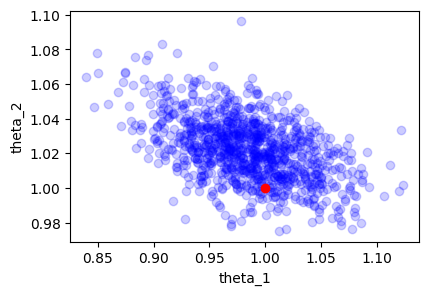

In [65]:
plot_theta_samples(theta_samples, theta_true, save_name=os.path.join(save_dirs.plots, "theta_samples_plot.pdf"))

Solution space posterior

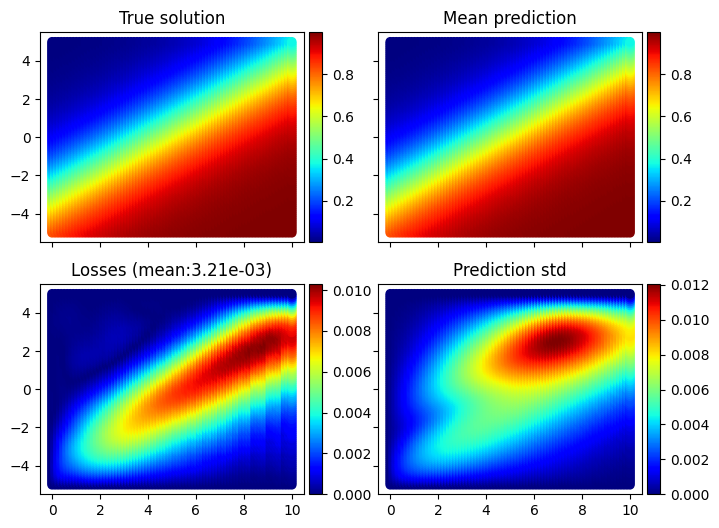

In [66]:
plot_us_posterior(test_data.Xs[:,::-1], test_data.us, us_samples, save_name=os.path.join(save_dirs.plots, f'posteriorPrediction.pdf'))

### Comparison with ground-truth solution data

In [67]:
gt_eval_results = ground_truth_evaluation(test_data.us, theta_true, us_samples, theta_samples)

Results evaluation against ground truth
u_rmse - mean/std     : 0.00616/0.00290
u_mpl  - mean/std     : 77140.99219/1864382.62500
theta_rmse - mean/std : 0.03453/0.02002
theta_entropy         : -4.24482


In [68]:
save_dict_to_txt(gt_eval_results, os.path.join(save_dirs.stats, f"ground_truth_evaluation.txt"))